<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 10</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Méthodes ensemblistes</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : bagging, forêt aléatoire, arbres extrêmement aléatoires, AdaBoost, gradient boosting, XGBoost, stacking et vote. Il permet également de régénérer les figures associées selon les conventions graphiques du livre. Le fil conducteur est le jeu de données <i>Wine</i>, avec la même séparation entraînement/test qu'au chapitre 6. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib`, `scikit-learn` et `xgboost`.  
**Installation complémentaire** : XGBoost s'installe avec `pip install xgboost`.  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration ; l'exécution complète prend moins d'une minute.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'scikit-learn', 'xgboost')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'font.size': 13,
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Reproductibilité
SEED = 42
np.random.seed(SEED)

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT = '#482878', '#21918c', '#5ec962'
BLEU    = '#3b528b'    # nuages de données / éléments neutres
MAGENTA = '#bf00bf'    # courbes de modèle
BORD = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b'}
ZONE = {VIOLET: '#d5cbe4', SARCELLE: '#c4e3e1', VERT: '#def2e0'}

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
scikit-learn       1.9.0
xgboost            3.4.0


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 10.1 : Arbre de décision seul contre bagging de 200 arbres</h3>

In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

data = load_wine()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.25,
    random_state=42, stratify=data.target)

arbre = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
acc_arbre = accuracy_score(y_test, arbre.predict(X_test))

bagging = BaggingClassifier(
    DecisionTreeClassifier(random_state=42),
    n_estimators=200, oob_score=True, random_state=42
).fit(X_train, y_train)
acc_bagging = accuracy_score(y_test, bagging.predict(X_test))
erreur_oob = 1 - bagging.oob_score_

# Dispersion des arbres individuels de l'ensemble
accs = [accuracy_score(y_test, e.predict(X_test)) for e in bagging.estimators_]

# --- Affichage ---
L = 57
print("=" * L)
print("Bagging d'arbres de décision (Wine)")
print("=" * L)
print(f"{'Arbre seul':<22}{acc_arbre:.3f}")
print(f"{'Bagging (200 arbres)':<22}{acc_bagging:.3f}")
print(f"{'Erreur OOB':<22}{erreur_oob:.3f}")
print("-" * L)
print(f"{'Arbres individuels':<22}min={min(accs):.3f}  moyenne={np.mean(accs):.3f}  max={max(accs):.3f}")
print("=" * L)

Bagging d'arbres de décision (Wine)
Arbre seul            0.956
Bagging (200 arbres)  1.000
Erreur OOB            0.060
---------------------------------------------------------
Arbres individuels    min=0.822  moyenne=0.923  max=1.000


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 10.2 : Forêt aléatoire et importance des variables</h3>

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

foret = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)
foret.fit(X_train, y_train)
acc_test = accuracy_score(y_test, foret.predict(X_test))
acc_oob = foret.oob_score_
importances = pd.Series(
    foret.feature_importances_, index=data.feature_names
).sort_values(ascending=False)

# --- Affichage ---
L = 35
print("=" * L)
print("Forêt aléatoire (Wine)")
print("=" * L)
print(f"{'Exactitude (test)':<20}{acc_test:.3f}")
print(f"{'Exactitude OOB':<20}{acc_oob:.3f}")
print("-" * L)
print("Importance des variables (top 5)")
print(importances.head(5).round(4).to_string())
print("=" * L)

Forêt aléatoire (Wine)
Exactitude (test)   1.000
Exactitude OOB      0.970
-----------------------------------
Importance des variables (top 5)
color_intensity    0.1760
flavanoids         0.1688
proline            0.1513
alcohol            0.1276
hue                0.0951


<h3><span style="font-size: 30px">&#127924;</span> Figure : Importance des variables de la forêt aléatoire</h3>

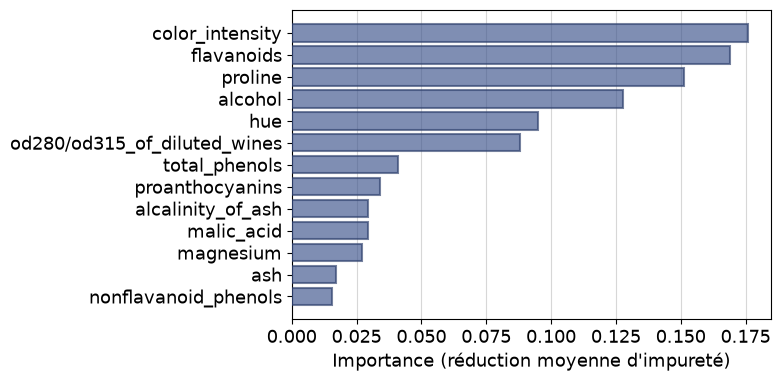

In [5]:
# Figure Fig_Chap10_ImportancesForet : classement complet des importances
imp = importances.sort_values(ascending=True)  # ordre croissant pour barh

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(imp.index, imp.values, color=BLEU, edgecolor=BORD[BLEU],
        linewidth=1.5, alpha=0.65, zorder=3)
ax.set_xlabel("Importance (réduction moyenne d'impureté)")
ax.grid(axis='x', alpha=0.5, zorder=0)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap10_ImportancesForet')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 10.3 : Arbres extrêmement aléatoires</h3>

In [6]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(n_estimators=200, random_state=42)
extra.fit(X_train, y_train)
print(f"Arbres extrêmement aléatoires : "
      f"{accuracy_score(y_test, extra.predict(X_test)):.3f}")

Arbres extrêmement aléatoires : 1.000


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 10.4 : AdaBoost avec des souches de décision</h3>

In [7]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=200, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)
print(f"Exactitude (test) : {accuracy_score(y_test, ada.predict(X_test)):.3f}")

Exactitude (test) : 0.978


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 10.5 : Gradient boosting</h3>

In [8]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=3, subsample=0.9, random_state=42)
gb.fit(X_train, y_train)
print(f"Exactitude (test) : {accuracy_score(y_test, gb.predict(X_test)):.3f}")

Exactitude (test) : 0.978


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 10.6 : XGBoost</h3>

In [9]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9,
    objective='multi:softprob', eval_metric='mlogloss',
    reg_lambda=1.0, random_state=42, n_jobs=-1)
xgb_clf.fit(X_train, y_train)
print(f"Exactitude (test) : {accuracy_score(y_test, xgb_clf.predict(X_test)):.3f}")

Exactitude (test) : 1.000


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 10.7 : Stacking de trois apprenants hétérogènes</h3>

In [10]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

stacking = StackingClassifier(
    estimators=[
        ('logistique', make_pipeline(StandardScaler(),
                                     LogisticRegression(max_iter=1000))),
        ('kppv', make_pipeline(StandardScaler(),
                               KNeighborsClassifier())),
        ('arbre', DecisionTreeClassifier(random_state=42))],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5)
stacking.fit(X_train, y_train)
print(f"Exactitude (test) : {accuracy_score(y_test, stacking.predict(X_test)):.3f}")

Exactitude (test) : 0.978


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 10.8 : Vote d'apprenants hétérogènes</h3>

In [11]:
from sklearn.ensemble import VotingClassifier

apprenants = [
    ('logistique', make_pipeline(StandardScaler(),
                                 LogisticRegression(max_iter=1000))),
    ('kppv', make_pipeline(StandardScaler(),
                           KNeighborsClassifier())),
    ('arbre', DecisionTreeClassifier(random_state=42))]

vote_dur = VotingClassifier(estimators=apprenants, voting='hard').fit(X_train, y_train)
acc_dur = accuracy_score(y_test, vote_dur.predict(X_test))

vote_souple = VotingClassifier(estimators=apprenants, voting='soft').fit(X_train, y_train)
acc_souple = accuracy_score(y_test, vote_souple.predict(X_test))

# Exactitude de chaque apprenant pris isolément
accs_individus = []
for nom, est in apprenants:
    est.fit(X_train, y_train)
    accs_individus.append((nom, accuracy_score(y_test, est.predict(X_test))))

# --- Affichage ---
L = 40
print("=" * L)
print("VotingClassifier (Wine)")
print("=" * L)
print(f"{'Vote majoritaire (hard)':<26}{acc_dur:.3f}")
print(f"{'Vote par moyenne (soft)':<26}{acc_souple:.3f}")
print("-" * L)
print("Apprenants individuels")
for nom, acc in accs_individus:
    print(f"{nom:<26}{acc:.3f}")
print("=" * L)

VotingClassifier (Wine)
Vote majoritaire (hard)   0.978
Vote par moyenne (soft)   0.956
----------------------------------------
Apprenants individuels
logistique                1.000
kppv                      0.933
arbre                     0.956


<h3><span style="font-size: 30px">&#127924;</span> Figure : Comparaison des exactitudes sur le jeu de données <i>Wine</i></h3>

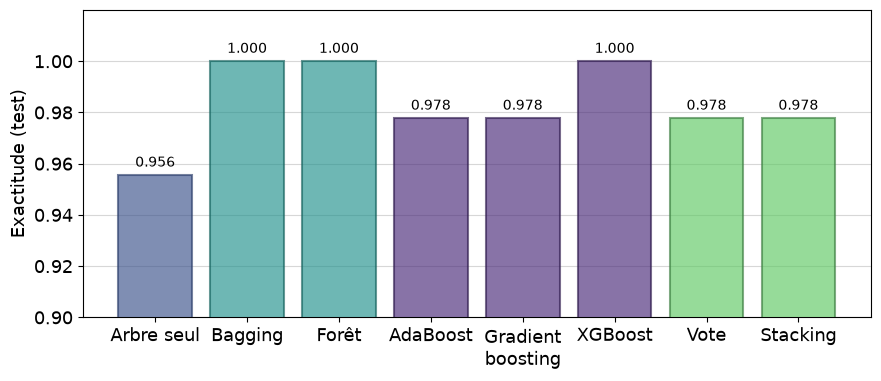

In [12]:
# Figure Fig_Chap10_Comparaison : l'arbre seul et les sept méthodes ensemblistes
modeles = {'Arbre seul': arbre, 'Bagging': bagging, 'Forêt': foret,
           'AdaBoost': ada, 'Gradient\nboosting': gb, 'XGBoost': xgb_clf,
           'Vote': vote_dur, 'Stacking': stacking}

exactitudes = [accuracy_score(y_test, m.predict(X_test))
               for m in modeles.values()]
couleurs = [BLEU, SARCELLE, SARCELLE, VIOLET, VIOLET, VIOLET, VERT, VERT]

fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.bar(modeles.keys(), exactitudes, color=couleurs,
              edgecolor=[BORD[c] for c in couleurs],
              linewidth=1.5, alpha=0.65, zorder=3)
for b, v in zip(bars, exactitudes):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.002, f'{v:.3f}',
            ha='center', va='bottom', fontsize=10)
ax.set_ylim(0.90, 1.02)
ax.set_yticks(np.arange(0.90, 1.001, 0.02))
ax.set_ylabel('Exactitude (test)')
ax.grid(axis='y', alpha=0.5, zorder=0)
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap10_Comparaison')

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 10.9 : Exactitude en fonction du nombre d'apprenants</h3>

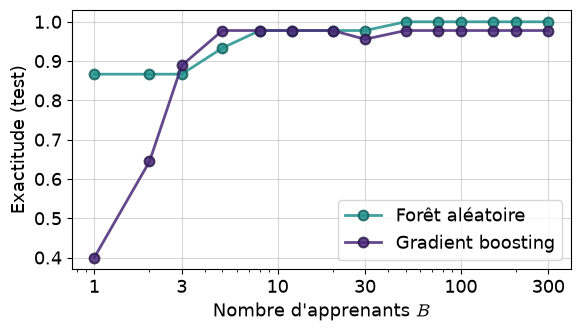

In [13]:
# Figure Fig_Chap10_NombreApprenants : effet du nombre d'apprenants B
liste_B = [1, 2, 3, 5, 8, 12, 20, 30, 50, 75, 100, 150, 200, 300]

exact_foret, exact_gb = [], []
for B in liste_B:
    f_B = RandomForestClassifier(n_estimators=B, random_state=42)
    f_B.fit(X_train, y_train)
    exact_foret.append(accuracy_score(y_test, f_B.predict(X_test)))
    g_B = GradientBoostingClassifier(n_estimators=B, learning_rate=0.05,
                                     max_depth=3, subsample=0.9,
                                     random_state=42)
    g_B.fit(X_train, y_train)
    exact_gb.append(accuracy_score(y_test, g_B.predict(X_test)))

fig, ax = plt.subplots(figsize=(6, 3.5))

ax.plot(liste_B, exact_foret, marker='o', markersize=7, color=SARCELLE,
        markeredgecolor=BORD[SARCELLE], markeredgewidth=1.5,
        linewidth=2, alpha=0.85, label='Forêt aléatoire', zorder=3)
ax.plot(liste_B, exact_gb, marker='o', markersize=7, color=VIOLET,
        markeredgecolor=BORD[VIOLET], markeredgewidth=1.5,
        linewidth=2, alpha=0.85, label='Gradient boosting', zorder=3)
ax.set_xscale('log')
ax.set_xticks([1, 3, 10, 30, 100, 300])
ax.set_xticklabels(['1', '3', '10', '30', '100', '300'])
ax.set_xlabel("Nombre d'apprenants $B$")
ax.set_ylabel('Exactitude (test)')
ax.grid(alpha=0.5, zorder=0)
ax.legend(loc='lower right')
fig.tight_layout()

# Sauvegarder la figure
save_figure(fig, 'Figures/Fig_Chap10_NombreApprenants')

plt.show()

<hr style='border-top:4px solid #1F77B4;'>